#### Function Trnasformation

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
dataset = pd.read_csv("loan.csv")
dataset.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP00001,Male,Yes,2,Graduate,Yes,16337,7648,574.0,360.0,0.0,Semiurban,N
1,LP00002,NaN,No,0,Graduate,NaN,24986,9550,261.0,360.0,1.0,Rural,Y
2,LP00003,Female,Yes,0,Graduate,No,8812,5115,74.0,NaN,1.0,Semiurban,Y


In [5]:
dataset.isnull().sum()

Loan_ID               0
Gender                9
Married              10
Dependents           10
Education             0
Self_Employed        17
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      7
Credit_History       10
Property_Area         0
Loan_Status           0
dtype: int64

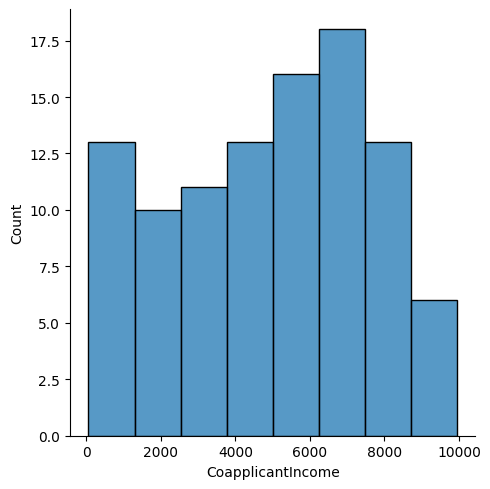

In [ ]:
# seaborn has update distplot -> displot or hisplot
sns.displot(dataset["CoapplicantIncome"])
plt.show()

In [8]:
# removing outlier
q1 = dataset["CoapplicantIncome"].quantile(0.25)
q3 = dataset["CoapplicantIncome"].quantile(0.75)

IQR = q3 - q1

min_r =q1 - (1.5*IQR)
max_r= q3 + (1.5 *IQR)

min_r,max_r

(np.float64(-3285.5), np.float64(13004.5))

In [10]:
dataset = dataset[dataset["CoapplicantIncome"]<= max_r]

In [11]:
# function Transformation(normal dist)
from sklearn.preprocessing import FunctionTransformer


#### Data is converted from non-Normal dist to Normal Dist curve by different methods like:-
##### Log Function, Square Function(Exponeential)

In [13]:
ft = FunctionTransformer(func = np.log1p)

In [14]:
ft.fit(dataset[["CoapplicantIncome"]])

,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None
,inv_kw_args,None


In [17]:
dataset["CoapplicantIncome_Tf"] =ft.transform(dataset[["CoapplicantIncome"]])

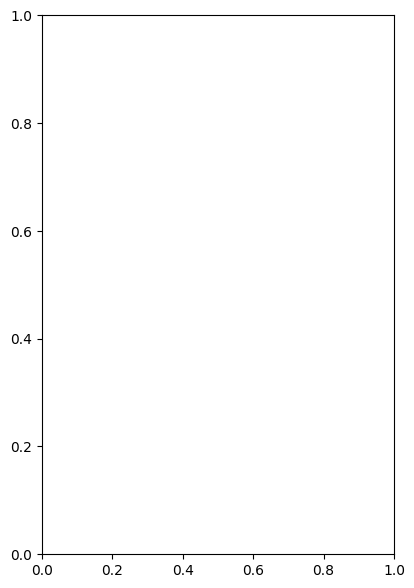

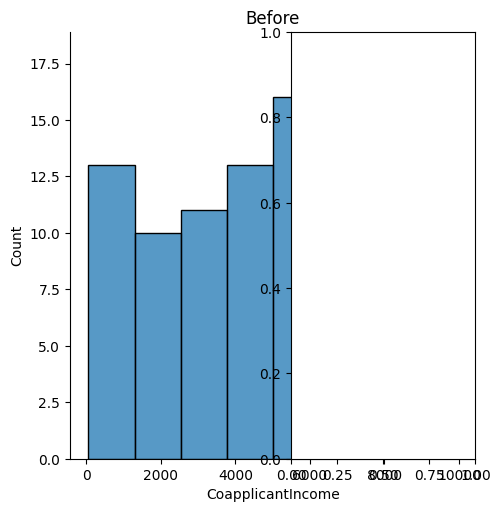

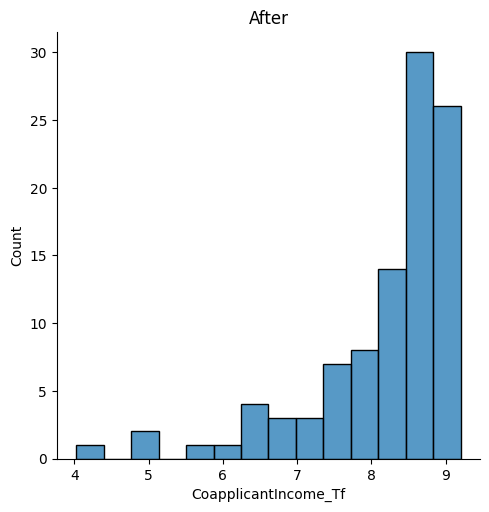

In [20]:
plt.figure(figsize = (10,7))
plt.subplot(1,2,1)
sns.displot(dataset["CoapplicantIncome"])
plt.title("Before")

plt.subplot(1,2,2)
sns.displot(dataset["CoapplicantIncome_Tf"])
plt.title("After")
plt.show()